In [ ]:
from google.colab import files
uploaded = files.upload()

TypeError: 'NoneType' object is not subscriptable

In [ ]:
import pandas as pd

df = pd.read_csv("Walmart DataSet.csv")
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

A) If the weekly sales are affected by the unemployment rate, if yes - which stores
are suffering the most?

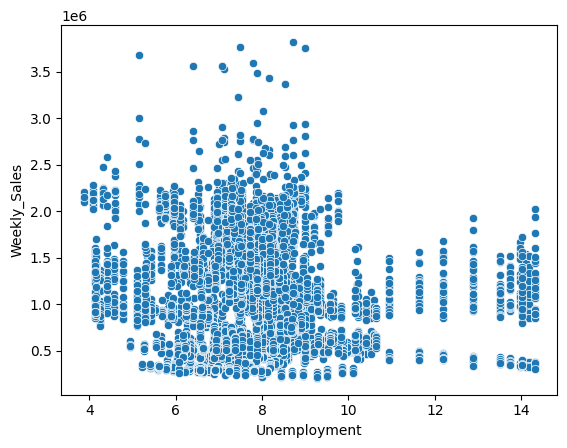

,Weekly_Sales,Unemployment
Weekly_Sales,1.000000,-0.106176
Unemployment,-0.106176,1.000000


In [ ]:
sns.scatterplot(x="Unemployment", y="Weekly_Sales", data=df)
plt.show()

df[['Weekly_Sales','Unemployment']].corr()

In [ ]:
impact = df.groupby("Store")[["Weekly_Sales","Unemployment"]].corr().iloc[0::2,-1]
impact.sort_values()

,,Unemployment
Store,,
38,Weekly_Sales,-0.785290
44,Weekly_Sales,-0.780076
39,Weekly_Sales,-0.384681
42,Weekly_Sales,-0.356355
41,Weekly_Sales,-0.350630
4,Weekly_Sales,-0.337015
17,Weekly_Sales,-0.263600
3,Weekly_Sales,-0.230413
37,Weekly_Sales,-0.221287


B)If the weekly sales show a seasonal trend, when and what could be the reason?

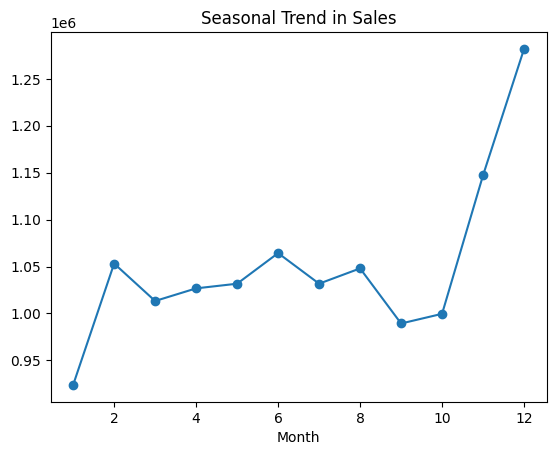

In [ ]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
df['Month'] = df['Date'].dt.month

monthly_sales = df.groupby('Month')['Weekly_Sales'].mean()

monthly_sales.plot(marker='o')
plt.title("Seasonal Trend in Sales")
plt.show()

c. Does temperature affect weekly sales?

In [ ]:
df[['Temperature','Weekly_Sales']].corr()

,Temperature,Weekly_Sales
Temperature,1.00000,-0.06381
Weekly_Sales,-0.06381,1.00000


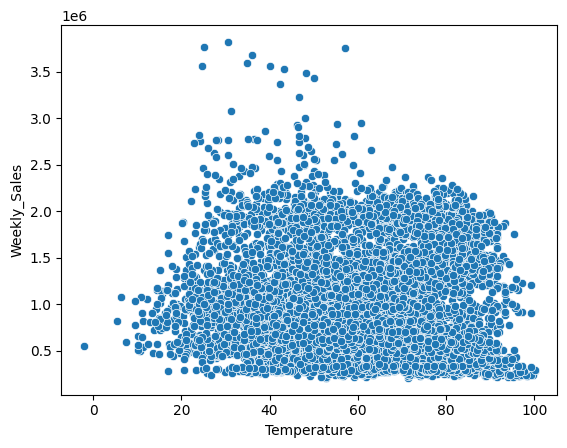

In [ ]:
sns.scatterplot(x="Temperature", y="Weekly_Sales", data=df)
plt.show()

d. Effect of Consumer Price Index (CPI)

In [ ]:
df[['CPI','Weekly_Sales']].corr()

,CPI,Weekly_Sales
CPI,1.000000,-0.072634
Weekly_Sales,-0.072634,1.000000


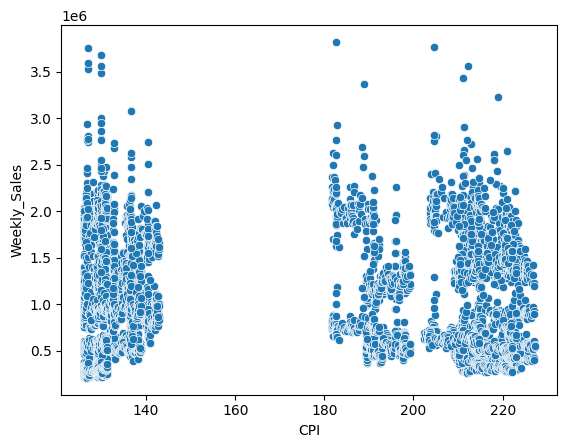

In [ ]:
sns.scatterplot(x="CPI", y="Weekly_Sales", data=df)
plt.show()

e. Top Performing Stores

In [ ]:
top_stores = df.groupby("Store")["Weekly_Sales"].sum().sort_values(ascending=False)

top_stores.head(5)

,Weekly_Sales
Store,
20,3.013978e+08
4,2.995440e+08
14,2.889999e+08
13,2.865177e+08
2,2.753824e+08


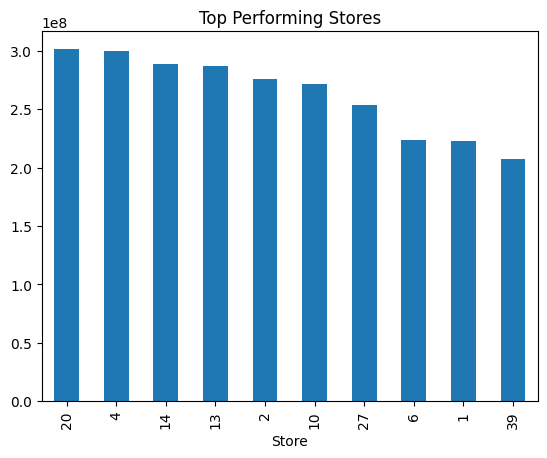

In [ ]:
top_stores.head(10).plot(kind='bar')
plt.title("Top Performing Stores")
plt.show()

f. Worst Performing Store

In [ ]:
top_stores.tail(1)

,Weekly_Sales
Store,
33,37160221.96


In [ ]:
highest = top_stores.max()
lowest = top_stores.min()

difference = highest - lowest
difference

264237570.49999997

2. Predictive Modeling (Forecast Next 12 Weeks)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

In [ ]:
X = df[['Temperature','Fuel_Price','CPI','Unemployment','Holiday_Flag']]
y = df['Weekly_Sales']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

In [ ]:
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [ ]:
pred = model.predict(X_test)

In [ ]:
mean_absolute_error(y_test,pred)

463211.0284658249

In [ ]:
future_data = X.tail(12)

forecast = model.predict(future_data)

forecast

array([ 970062.69940429,  972237.4423894 ,  974598.32189512,
        972308.5635143 , 1044299.8817737 ,  977829.97380784,
        979546.13636167,  979793.54679735,  980284.11687481,
        988730.88931643,  987126.85714478,  985364.63071687])

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Walmart DataSet.csv to Walmart DataSet.csv


Store Segmentation

In [ ]:
import pandas as pd
df = pd.read_csv("Walmart DataSet.csv")

# Store Segmentation based on Total Sales

store_sales = df.groupby("Store")["Weekly_Sales"].sum().reset_index()

# Create performance categories
store_sales['Category'] = pd.qcut(store_sales['Weekly_Sales'],
                                  q=3,
                                  labels=['Low Performing','Medium Performing','High Performing'])

store_sales.sort_values(by="Weekly_Sales", ascending=False)

,Store,Weekly_Sales,Category
19,20,3.013978e+08,High Performing
3,4,2.995440e+08,High Performing
13,14,2.889999e+08,High Performing
12,13,2.865177e+08,High Performing
1,2,2.753824e+08,High Performing
9,10,2.716177e+08,High Performing
26,27,2.538559e+08,High Performing
5,6,2.237561e+08,High Performing
0,1,2.224028e+08,High Performing
38,39,2.074455e+08,High Performing


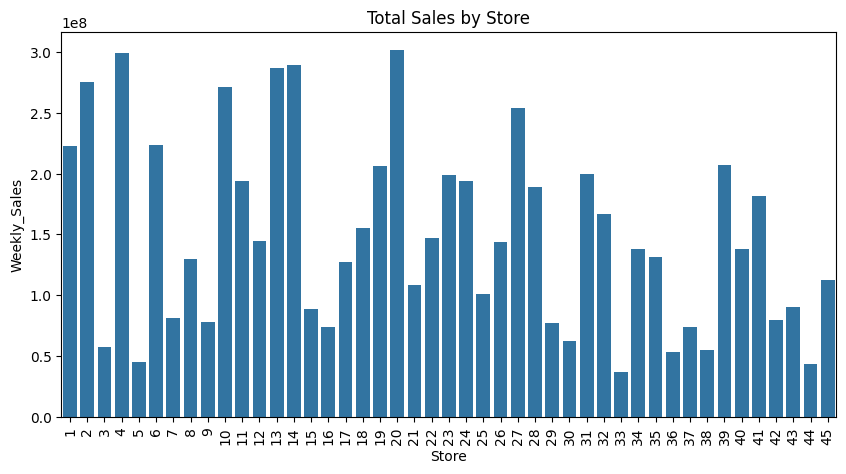

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.barplot(x="Store", y="Weekly_Sales", data=store_sales)
plt.title("Total Sales by Store")
plt.xticks(rotation=90)
plt.show()

Time Series Forecasting (ARIMA)

In [ ]:
!pip install statsmodels

Prepare Data

In [10]:
from statsmodels.tsa.arima.model import ARIMA

# Convert Date
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

# Aggregate weekly sales
ts = df.groupby('Date')['Weekly_Sales'].sum().sort_index()

print(ts.head())

Date
2010-02-05    49750740.50
2010-02-12    48336677.63
2010-02-19    48276993.78
2010-02-26    43968571.13
2010-03-05    46871470.30
Name: Weekly_Sales, dtype: float64


Plot Time Series

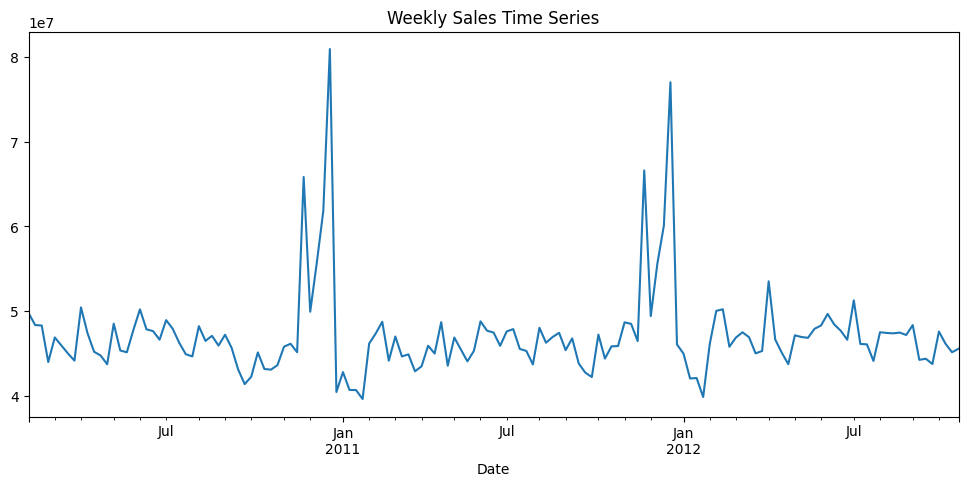

In [11]:
plt.figure(figsize=(12,5))
ts.plot()
plt.title("Weekly Sales Time Series")
plt.show()

Train ARIMA Model

In [12]:
model = ARIMA(ts, order=(5,1,0))
model_fit = model.fit()

print(model_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:           Weekly_Sales   No. Observations:                  143
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -2402.605
Date:                Tue, 10 Mar 2026   AIC                           4817.211
Time:                        06:08:50   BIC                           4834.946
Sample:                    02-05-2010   HQIC                          4824.417
                         - 10-26-2012                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3061      0.042     -7.365      0.000      -0.388      -0.225
ar.L2         -0.2088      0.047     -4.413      0.000      -0.302      -0.116
ar.L3         -0.1829      0.058     -3.157      0.0

Forecast Future Sales

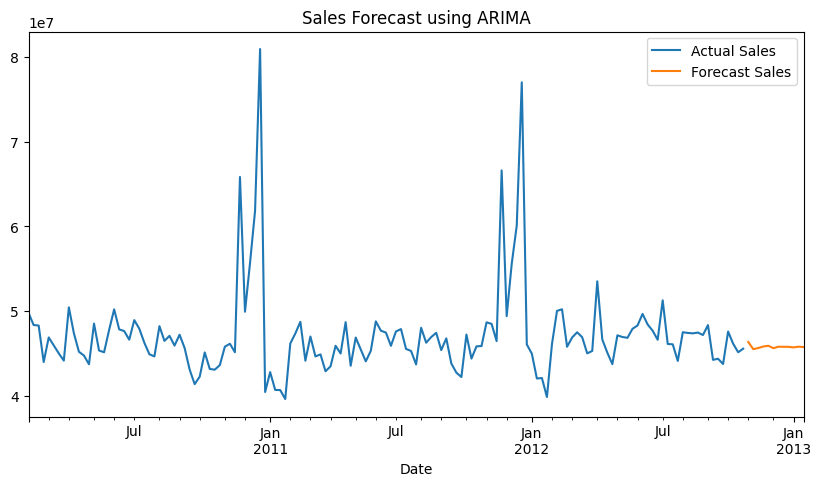

In [13]:
forecast = model_fit.forecast(steps=12)

plt.figure(figsize=(10,5))
ts.plot(label="Actual Sales")
forecast.plot(label="Forecast Sales")
plt.legend()
plt.title("Sales Forecast using ARIMA")
plt.show()

SARIMA Model (Seasonality)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


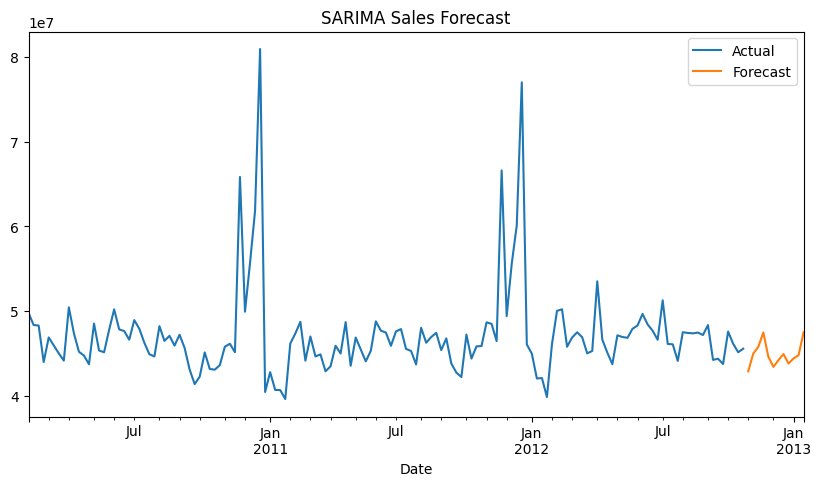

In [14]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(ts,
                order=(1,1,1),
                seasonal_order=(1,1,1,12))

result = model.fit()

forecast = result.forecast(12)

plt.figure(figsize=(10,5))
ts.plot(label="Actual")
forecast.plot(label="Forecast")
plt.legend()
plt.title("SARIMA Sales Forecast")
plt.show()